# 02 — Du bao 4 mat hang: cac mo hinh + News Sentiment

> Chon mot gia tri trong `CONFIG['target']`, sau do Run All. Moi lan chay se cap nhat file rieng theo target va bang tong hop chung.

**Muc tieu:** Test tren du lieu moi (`clean_data_exo_ver1.csv`) + news sentiment, so sanh cac nhom mo hinh tren 4 chi so **MAE, MAPE, SMAPE, R2** (giu them RMSE).

**Mo hinh:**
- Thong ke: **SARIMA**, **ARIMAX** (one-step-ahead, statsmodels)
- Tuyen tinh: **Ridge/Linear Regression** (baseline lien tuc)
- Phan loai huong: **Logistic Regression** (du bao tang/giam — bao cao Accuracy/F1)
- Cay: **LightGBM**
- Deep Learning: **LSTM** (Keras), **PatchTST** & **TFT** (PyTorch / neuralforecast)

**News:** notebook tu dong left-join `news-crawler/data/daily_features.csv` theo ngay (0-fill) neu co; neu khong co thi bo qua, khong loi.

> Tat ca mo hinh deu danh gia **one-step-ahead (H=1)** tren cung khung thoi gian test de so sanh cong bang. Doi `HORIZON` trong CONFIG de chay horizon khac.

Bo sung model **Jump-Gated ARIMAX-CatBoost**: model hybrid dung ARIMAX + CatBoost va co tang nhan dien ngay gia nhay manh.

In [1]:
#%pip install -r ../requirements.txt

In [2]:
import os
os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")   # repo models use Keras-2 API (TF 2.17 ships Keras 3)
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

# === Setup ===
import warnings; warnings.filterwarnings("ignore")
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

# Cai dat (chay 1 lan neu thieu thu vien):
# pip install lightgbm statsmodels scikit-learn tensorflow catboost
# pip install neuralforecast   # PatchTST + TFT (keo theo torch + lightning)

TARGETS = ["MG95", "MG92", "DO 0.001%", "DO 0.05%"]

CONFIG = {
    "targets":     TARGETS,
    "target":      os.environ.get("FORECAST_TARGET", TARGETS[0]),
    "run_all_targets": False,  # notebook thu nghiem: chay mot target moi lan
    "horizon":     1,            # one-step-ahead
    "seq_len":     30,           # do dai chuoi cho LSTM / PatchTST / TFT
    "train_ratio": 0.80,
    "val_ratio":   0.10,
    "exog_cols":   ["WTI", "USD_Index", "GPR", "BRT DTD", "Brent_EU_Daily"],
    "seasonal":    5,            # chu ky tuan giao dich (5 ngay)
    "lstm_epochs": 40,
    "nf_steps":    300,          # max_steps cho PatchTST/TFT (tang de chinh xac hon)
    "tune_lgbm":   False,        # True = chay Optuna (cham hon)
}
if CONFIG["target"] not in TARGETS:
    raise ValueError(f"Target khong hop le: {CONFIG['target']}. Chon mot trong {TARGETS}")
print("ROOT =", ROOT)
print("CONFIG =", CONFIG)

ROOT = d:\oil\Oil-forcasting
CONFIG = {'targets': ['MG95', 'MG92', 'DO 0.001%', 'DO 0.05%'], 'target': 'MG95', 'run_all_targets': False, 'horizon': 1, 'seq_len': 30, 'train_ratio': 0.8, 'val_ratio': 0.1, 'exog_cols': ['WTI', 'USD_Index', 'GPR', 'BRT DTD', 'Brent_EU_Daily'], 'seasonal': 5, 'lstm_epochs': 40, 'nf_steps': 300, 'tune_lgbm': False}


## 1. Load du lieu exogenous + (tuy chon) News

In [3]:
from src.data_loader import load_and_engineer

TARGET = CONFIG["target"]
TARGET_SLUG = TARGET.replace("%", "pct").replace(" ", "_").replace(".", "_")
TARGET_RESULT_DIR = ROOT / "results" / "by_target" / TARGET_SLUG
TARGET_CHART_DIR = ROOT / "results" / "charts" / TARGET_SLUG
TARGET_RESULT_DIR.mkdir(parents=True, exist_ok=True)
TARGET_CHART_DIR.mkdir(parents=True, exist_ok=True)
df = load_and_engineer(target_col=TARGET)  # data + feature engineering theo dung target
print("Exo data:", df.shape, "|", df.index.min().date(), "->", df.index.max().date())

# --- News join (tuy chon, auto-skip neu thieu) ---
news_path = ROOT / "news-crawler" / "data" / "daily_features.csv"
news_cols = []
if news_path.exists():
    news = pd.read_csv(news_path, parse_dates=["date"]).set_index("date")
    news = news[~news.index.duplicated(keep="last")].sort_index()
    df = df.join(news, how="left")
    news_cols = list(news.columns)
    df[news_cols] = df[news_cols].fillna(0.0)   # ngay khong co tin -> 0
    cov = (df[news_cols].abs().sum(axis=1) > 0).mean() * 100
    print(f"News joined: +{len(news_cols)} cot | phu song ~{cov:.1f}% so ngay (con lai = 0)")
else:
    print("KHONG tim thay daily_features.csv -> chay khong co news.")
    print("Tao bang: news-crawler -> crawl -> sentiment.py -> aggregate.py")
df.tail(3)

Exo data: (4619, 52) | 2008-06-12 -> 2026-05-08
News joined: +16 cot | phu song ~87.7% so ngay (con lai = 0)


,MG97,MG95,MG92,NAPHTHA,KERO,DO 0.001%,DO 0.05%,FO 180,BRT DTD,BRT KH,...,political_economy_sent_sum,political_economy_intensity,natural_disaster_n,natural_disaster_sent_mean,natural_disaster_sent_sum,natural_disaster_intensity,all_n,all_sent_mean,all_sent_sum,all_intensity
Ngày,,,,,,,,,,,,,,,,,,,,,
2026-05-06,133.22,134.40,133.34,129.12,200.54,157.04,146.90,662.85,117.485,109.05,...,0.0,0.0,0,0.0,0.0,0.0,2,0.1500,0.3,0.3
2026-05-07,133.22,127.53,126.14,129.12,200.54,149.29,138.77,662.85,117.485,109.05,...,0.0,0.0,0,0.0,0.0,0.0,5,-0.0600,-0.3,2.1
2026-05-08,133.22,126.06,124.48,129.12,200.54,153.97,142.95,662.85,117.485,109.05,...,-1.1,1.1,0,0.0,0.0,0.0,7,-0.3857,-2.7,2.7


## 2. Chi so danh gia — MAE, RMSE, MAPE, SMAPE, R2 (+ phan loai)

In [4]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score)

def reg_metrics(y_true, y_pred, name):
    yt = np.asarray(y_true, float); yp = np.asarray(y_pred, float)
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mape = np.mean(np.abs((yt - yp) / (np.abs(yt) + 1e-8))) * 100
    smape = np.mean(2.0 * np.abs(yp - yt) / (np.abs(yt) + np.abs(yp) + 1e-8)) * 100
    return {"Model": name, "MAE": round(mae,4), "RMSE": round(rmse,4),
            "MAPE(%)": round(mape,4), "SMAPE(%)": round(smape,4),
            "R2": round(r2_score(yt, yp),4)}

def clf_metrics(y_true, y_pred, name):
    return {"Model": name,
            "Accuracy": round(accuracy_score(y_true, y_pred),4),
            "F1": round(f1_score(y_true, y_pred, zero_division=0),4)}

results = []        # cac mo hinh regression
clf_results = []    # logistic (phan loai huong)
print("Metrics ready.")

Metrics ready.


## 3. Chuan bi du lieu — chronological split (no leakage) + scaling
RobustScaler fit **chi tren train**. Chia theo thoi gian, khong random.

In [5]:
from sklearn.preprocessing import RobustScaler

H = CONFIG["horizon"]
feature_cols = [c for c in df.columns if c != TARGET]

work = df.copy()
work["__y"] = work[TARGET].shift(-H)     # target = gia mat hang dang chon tai t+H
work = work.dropna(subset=["__y"])

n   = len(work)
ntr = int(n * CONFIG["train_ratio"])
nvl = int(n * CONFIG["val_ratio"])
tr, vl, te = work.iloc[:ntr], work.iloc[ntr:ntr+nvl], work.iloc[ntr+nvl:]

scaler_X = RobustScaler().fit(tr[feature_cols])
Xtr = scaler_X.transform(tr[feature_cols])
Xvl = scaler_X.transform(vl[feature_cols])
Xte = scaler_X.transform(te[feature_cols])
ytr, yvl, yte = tr["__y"].values, vl["__y"].values, te["__y"].values
test_dates = te.index

# nhan huong tang/giam cho Logistic
dir_tr = (tr["__y"].values > tr[TARGET].values).astype(int)
dir_te = (te["__y"].values > te[TARGET].values).astype(int)

print(f"Features: {len(feature_cols)} (news: {len(news_cols)})")
print(f"Train {len(tr)} | Val {len(vl)} | Test {len(te)}")
print(f"Test period: {test_dates.min().date()} -> {test_dates.max().date()}")
print(f"Test up-rate (baseline cho Logistic): {dir_te.mean():.3f}")

Features: 67 (news: 16)
Train 3694 | Val 461 | Test 463
Test period: 2024-07-24 -> 2026-05-07
Test up-rate (baseline cho Logistic): 0.544


## 4. Mo hinh thong ke — ARIMAX & SARIMA (one-step-ahead)
Fit tren train, danh gia one-step-ahead tren test bang `append(refit=False)` — cong bang voi cac mo hinh H=1.

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

exog_cols = [c for c in CONFIG["exog_cols"] if c in df.columns]
y_full  = df[TARGET].reset_index(drop=True).astype(float)
ex_full = df[exog_cols].reset_index(drop=True).astype(float)
N = len(y_full); n_test = len(te); split = N - n_test
y_te_arima = y_full.iloc[split:].values

# --- ARIMAX (co exog) ---
try:
    res = SARIMAX(y_full.iloc[:split], exog=ex_full.iloc[:split], order=(2,1,2),
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=80)
    res2 = res.append(y_full.iloc[split:], exog=ex_full.iloc[split:], refit=False)
    pred_ax = res2.predict(start=split, end=N-1, exog=ex_full.iloc[split:]).values
    results.append(reg_metrics(y_te_arima, pred_ax, "ARIMAX"))
    print("ARIMAX:", results[-1])
except Exception as e:
    print("ARIMAX skipped:", e)

# --- SARIMA (seasonal, khong exog) ---
try:
    res_s = SARIMAX(y_full.iloc[:split], order=(1,1,1),
                    seasonal_order=(1,0,1,CONFIG["seasonal"]),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=80)
    res_s2 = res_s.append(y_full.iloc[split:], refit=False)
    pred_sa = res_s2.predict(start=split, end=N-1).values
    results.append(reg_metrics(y_te_arima, pred_sa, "SARIMA"))
    print("SARIMA:", results[-1])
except Exception as e:
    print("SARIMA skipped:", e)

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMAX: {'Model': 'ARIMAX', 'MAE': 1.4311, 'RMSE': np.float64(2.8239), 'MAPE(%)': np.float64(1.4614), 'SMAPE(%)': np.float64(1.4596), 'R2': 0.975}
SARIMA: {'Model': 'SARIMA', 'MAE': 1.5088, 'RMSE': np.float64(3.0465), 'MAPE(%)': np.float64(1.552), 'SMAPE(%)': np.float64(1.5508), 'R2': 0.9709}


## 5. Jump-Gated ARIMAX-CatBoost

Model hybrid moi: ARIMAX du bao nen, CatBoost sua sai so, sau do them mot cong phu de nhan dien ngay gia co kha nang nhay manh. Ket qua duoc append vao bang so sanh ben duoi.

In [7]:
try:
    from src.models.jump_gated_arimax_catboost import (
        JumpGatedConfig,
        run_jump_gated_arimax_catboost,
    )

    jump_cfg = JumpGatedConfig(
        target=TARGET,
        horizon=H,
        train_ratio=CONFIG["train_ratio"],
        val_ratio=CONFIG["val_ratio"],
        exog_cols=CONFIG["exog_cols"],
        arimax_order=(2, 1, 2),
    )
    jump_result = run_jump_gated_arimax_catboost(
        load_and_engineer(target_col=TARGET),
        root=ROOT,
        config=jump_cfg,
        progress=True,
    )
    jump_row = jump_result["metrics"].query('Model == "Jump-Gated ARIMAX-CatBoost"').iloc[0].to_dict()
    results.append({k: jump_row[k] for k in ["Model", "MAE", "RMSE", "MAPE(%)", "SMAPE(%)", "R2"]})
    print("Jump-Gated ARIMAX-CatBoost:", results[-1])
except Exception as e:
    jump_result = None
    print("Jump-Gated ARIMAX-CatBoost skipped:", repr(e))

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


OOF fold 1: 2017-04-25 -> 2018-10-03 | MAE=0.7152
OOF fold 2: 2018-10-04 -> 2020-03-19 | MAE=1.1116
OOF fold 3: 2020-03-20 -> 2021-09-01 | MAE=1.0247
OOF fold 4: 2021-09-02 -> 2023-02-10 | MAE=2.1791


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


OOF fold 5: 2023-02-13 -> 2024-07-24 | MAE=1.2504
Jump-Gated ARIMAX-CatBoost MAE=1.2571
Jump-Gated ARIMAX-CatBoost: {'Model': 'Jump-Gated ARIMAX-CatBoost', 'MAE': 1.2571, 'RMSE': 2.6541, 'MAPE(%)': 1.2615, 'SMAPE(%)': 1.2603, 'R2': 0.9779}


## 5. Baseline tuyen tinh — Ridge / Linear Regression

In [8]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0).fit(Xtr, ytr)
results.append(reg_metrics(yte, ridge.predict(Xte), "Ridge (Linear)"))
print(results[-1])

{'Model': 'Ridge (Linear)', 'MAE': 1.5451, 'RMSE': np.float64(3.0974), 'MAPE(%)': np.float64(1.508), 'SMAPE(%)': np.float64(1.5226), 'R2': 0.9699}


## 6. Logistic Regression — phan loai huong (tang/giam)
Day la bai toan **phan loai**, bao cao Accuracy / F1 (khong dung MAPE/R2).

In [9]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr, dir_tr)
clf_results.append(clf_metrics(dir_te, clf.predict(Xte), "LogisticRegression (huong)"))
print(clf_results[-1], "| baseline up-rate =", round(dir_te.mean(),3))

{'Model': 'LogisticRegression (huong)', 'Accuracy': 0.6242, 'F1': 0.5877} | baseline up-rate = 0.544


## 7. LightGBM

In [10]:
import lightgbm as lgb
if CONFIG["tune_lgbm"]:
    from src.models.baseline_lgbm import tune_lgbm, train_lgbm
    bp = tune_lgbm(Xtr, ytr, Xvl, yvl, n_trials=40)["best_params"]
    lgbm = train_lgbm(Xtr, ytr, Xvl, yvl, bp)
else:
    lgbm = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, max_depth=7,
                             num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                             min_child_samples=20, random_state=42, n_jobs=-1, verbose=-1)
    lgbm.fit(Xtr, ytr, eval_set=[(Xvl, yvl)],
             callbacks=[lgb.early_stopping(50, verbose=False)])
results.append(reg_metrics(yte, lgbm.predict(Xte), "LightGBM"))
print(results[-1])

{'Model': 'LightGBM', 'MAE': 2.2288, 'RMSE': np.float64(4.3114), 'MAPE(%)': np.float64(2.2007), 'SMAPE(%)': np.float64(2.2508), 'R2': 0.9416}


## 8. LSTM (Keras)
Dung sliding window `make_windows` tu `src.data_loader`. Tu dong bo qua neu thieu TensorFlow.

In [11]:
try:
    import tensorflow as tf
    from tensorflow.keras import layers, Model
    from src.data_loader import make_windows

    SEQ = CONFIG["seq_len"]
    n_df = len(df); ntr_df = int(n_df * CONFIG["train_ratio"])
    sy = RobustScaler().fit(df[[TARGET]].iloc[:ntr_df])      # scale y tren train
    Xall = scaler_X.transform(df[feature_cols].values)
    yall = sy.transform(df[[TARGET]].values).flatten()

    Xw, yw = make_windows(Xall, yall, time_steps=SEQ, horizon=H)
    nW = len(Xw); a = int(nW*0.8); b = int(nW*0.1)
    Xw_tr, Xw_vl, Xw_te = Xw[:a], Xw[a:a+b], Xw[a+b:]
    yw_tr, yw_vl, yw_te = yw[:a], yw[a:a+b], yw[a+b:]

    tf.random.set_seed(42); tf.keras.backend.clear_session()
    inp = layers.Input((SEQ, len(feature_cols)))
    x = layers.LSTM(64, return_sequences=True)(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(32)(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(1)(x)
    lstm = Model(inp, out); lstm.compile(optimizer="adam", loss="mse")
    es = tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)
    lstm.fit(Xw_tr, yw_tr, validation_data=(Xw_vl, yw_vl),
             epochs=CONFIG["lstm_epochs"], batch_size=64, callbacks=[es], verbose=0)

    pred = sy.inverse_transform(lstm.predict(Xw_te, verbose=0)).flatten()
    ytru = sy.inverse_transform(yw_te.reshape(-1,1)).flatten()
    results.append(reg_metrics(ytru, pred, "LSTM"))
    print(results[-1])
except Exception as e:
    print("LSTM skipped:", repr(e))


{'Model': 'LSTM', 'MAE': 4.4189, 'RMSE': np.float64(8.0032), 'MAPE(%)': np.float64(4.3694), 'SMAPE(%)': np.float64(4.4413), 'R2': 0.8}


## 9. PatchTST & TFT (PyTorch / neuralforecast)
One-step-ahead bang `cross_validation` (h=1, step_size=1). Tu dong bo qua neu thieu `neuralforecast`.

> neuralforecast can tan suat deu. Du lieu gia dau co ngay nghi -> notebook resample sang business-day (`B`) va ffill de tranh loi. Tang `CONFIG['nf_steps']` de chinh xac hon.

In [12]:
try:
    from neuralforecast import NeuralForecast
    from neuralforecast.models import PatchTST, TFT

    nf_exog = [c for c in CONFIG["exog_cols"] if c in df.columns]
    base = df[[TARGET] + nf_exog].copy()
    base = base.asfreq("B").ffill()          # tan suat deu (business day)
    long = base.reset_index()
    long.columns = ["ds"] + [TARGET] + nf_exog
    long["unique_id"] = TARGET
    long["y"] = long[TARGET]
    long = long[["unique_id", "ds", "y"] + nf_exog]

    n_test = min(len(te), 250)               # gioi han so window cho nhanh
    common = dict(h=H, input_size=CONFIG["seq_len"], max_steps=CONFIG["nf_steps"],
                  scaler_type="robust", hist_exog_list=nf_exog, enable_progress_bar=False)
    nf = NeuralForecast(models=[PatchTST(**common), TFT(**common)], freq="B")
    cv = nf.cross_validation(df=long, n_windows=n_test, step_size=1)

    for mname in ["PatchTST", "TFT"]:
        if mname in cv.columns:
            sub = cv.dropna(subset=[mname])
            results.append(reg_metrics(sub["y"].values, sub[mname].values, mname))
            print(results[-1])
except Exception as e:
    print("PatchTST/TFT skipped (can: pip install neuralforecast):", repr(e))

PatchTST/TFT skipped (can: pip install neuralforecast): ModuleNotFoundError("No module named 'neuralforecast'")


## 10. So sanh ket qua + bieu do

=== Regression (test: 2024-07-24 -> 2026-05-07 ) ===


,Target,MAE,RMSE,MAPE(%),SMAPE(%),R2
Model,,,,,,
Jump-Gated ARIMAX-CatBoost,MG95,1.2571,2.6541,1.2615,1.2603,0.9779
ARIMAX,MG95,1.4311,2.8239,1.4614,1.4596,0.9750
Ridge (Linear),MG95,1.5451,3.0974,1.5080,1.5226,0.9699
SARIMA,MG95,1.5088,3.0465,1.5520,1.5508,0.9709
LightGBM,MG95,2.2288,4.3114,2.2007,2.2508,0.9416
LSTM,MG95,4.4189,8.0032,4.3694,4.4413,0.8000



=== Logistic (phan loai huong) ===


,Accuracy,F1
Model,,
LogisticRegression (huong),0.6242,0.5877


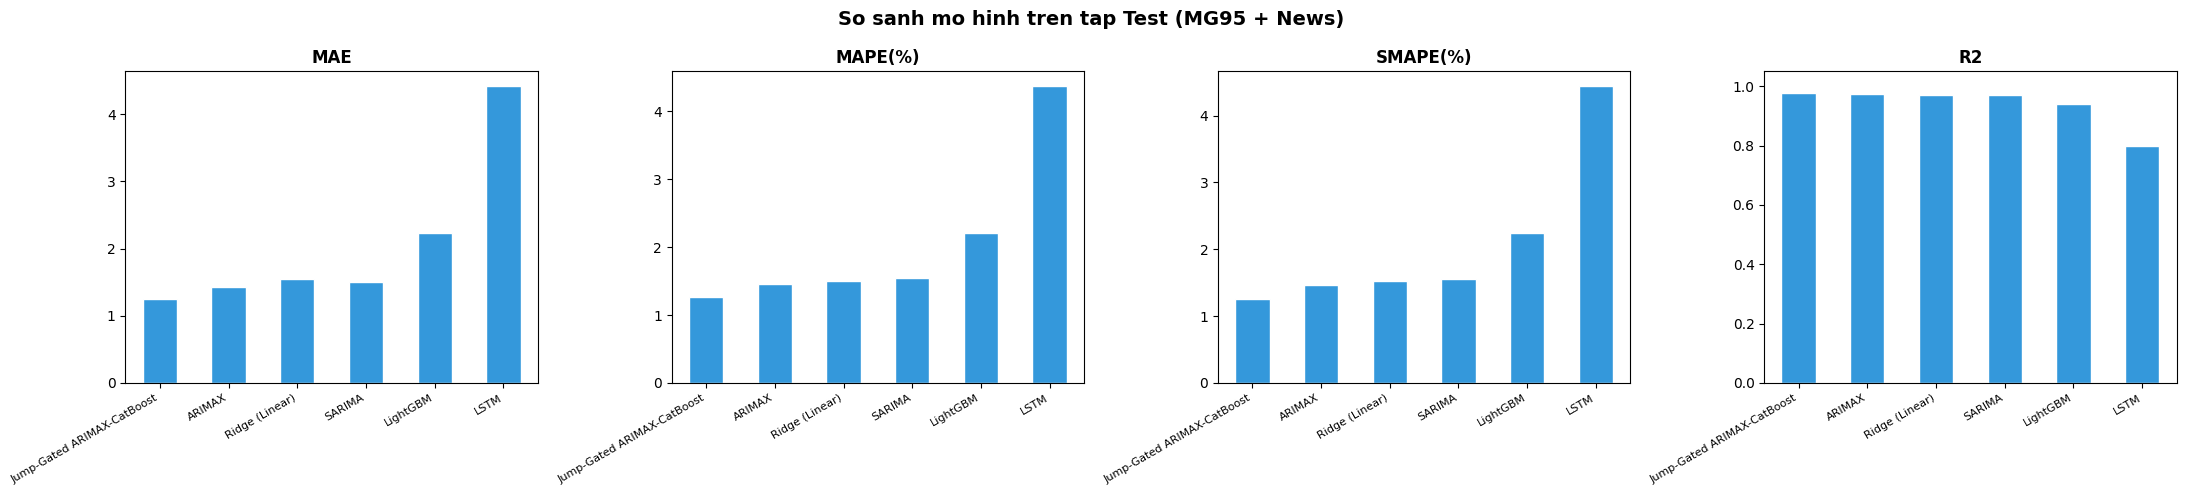

Saved -> d:\oil\Oil-forcasting\results\by_target\MG95\model_comparison_news.csv
Updated -> d:\oil\Oil-forcasting\results\model_comparison_news_all_targets.csv
Saved chart -> d:\oil\Oil-forcasting\results\charts\MG95\model_comparison_news.png


In [13]:
import matplotlib.pyplot as plt

res_df = pd.DataFrame(results).set_index("Model").sort_values("MAPE(%)")
res_df.insert(0, "Target", TARGET)
print("=== Regression (test:", test_dates.min().date(), "->", test_dates.max().date(), ") ===")
display(res_df)

target_csv = TARGET_RESULT_DIR / "model_comparison_news.csv"
res_df.to_csv(target_csv)

combined_path = ROOT / "results" / "model_comparison_news_all_targets.csv"
current_rows = res_df.reset_index()
if combined_path.exists():
    previous_rows = pd.read_csv(combined_path)
    previous_rows = previous_rows[previous_rows["Target"] != TARGET]
    combined_rows = pd.concat([previous_rows, current_rows], ignore_index=True)
else:
    combined_rows = current_rows
combined_rows.to_csv(combined_path, index=False)

if TARGET == "MG95":
    res_df.drop(columns=["Target"]).to_csv(ROOT / "results" / "model_comparison_news.csv")

if clf_results:
    print("\n=== Logistic (phan loai huong) ===")
    display(pd.DataFrame(clf_results).set_index("Model"))

mets = ["MAE", "MAPE(%)", "SMAPE(%)", "R2"]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, m in zip(axes, mets):
    vals = res_df[m]
    vals.plot.bar(ax=ax, color="#3498DB", edgecolor="white")
    ax.set_title(m, fontweight="bold"); ax.set_xlabel("")
    ax.set_xticklabels(res_df.index, rotation=30, ha="right", fontsize=8)
    if m == "R2": ax.set_ylim(min(0, vals.min()), 1.05)
plt.suptitle(f"So sanh mo hinh tren tap Test ({TARGET} + News)", fontsize=14, fontweight="bold")
plt.tight_layout()
chart_path = TARGET_CHART_DIR / "model_comparison_news.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
if TARGET == "MG95":
    plt.savefig(ROOT / "results" / "charts" / "model_comparison_news.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {target_csv}")
print(f"Updated -> {combined_path}")
print(f"Saved chart -> {chart_path}")

## 11. Ket qua Code Review (tom tat)

**src/ nhin chung tot:** chronological split chong leakage, RobustScaler fit-tren-train, feature engineering phong phu (lag/MA/ROC/crack-spread/cyclical), Optuna cho LightGBM, Walk-Forward + Multi-Horizon.

**Da sua / khuyen nghi:**
- **Them SMAPE** vao `evaluation.compute_metrics` (da patch) + sua MAPE dung `abs(y_true)` o mau so.
- `evaluate_multihorizon` nhan `n_train`,`n_val` nhung khong dung (tu tinh lai 0.8/0.1) — nen bo tham so thua de tranh nham.
- `build_pipeline`: scaler fit tren 80% theo **so dong df**, con split lai theo 80% **so window** — lech bien nho; nen thong nhat moc cat.
- `DOW_sin/cos` chia cho 5 (tuan giao dich) nhung du lieu co the chua ca cuoi tuan — kiem tra lai tan suat.
- `make_multihorizon_targets` tao cot `MG95_H*` ngay tren df; neu goi truoc khi chon `feature_cols` se ro ri target — giu thu tu hien tai (khong goi trong build_pipeline) la dung.
- DL (iTransformer/GUMNet) dung `Lambda` voi tf ops -> kho serialize khi luu model; can custom layer neu muon `model.save()`.

**Ghi chu mo hinh:**
- ARIMAX/SARIMA danh gia one-step-ahead (cong bang voi ML/DL H=1).
- Logistic Regression la **phan loai huong** (Accuracy/F1), khong phai du bao gia.
- Gia cua mat hang dang chon co tu tuong quan cao o lag-1; can xem them horizon xa va cac giai doan bien dong de danh gia day du.